In [1]:
!pip install numpy==1.26.4 scipy==1.13.0 albumentations==1.4.0 --force-reinstall --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 218.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 241.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 218.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 265.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 216.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 221.8 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.6/806.6 kB 276.0 MB/s eta 0:00:00
   ━━━━━━━━━━

In [10]:
!pip install -q albumentations

import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [11]:
data_dir = "/kaggle/input/coco-2017-dataset/coco2017"
img_dir = os.path.join(data_dir, "train2017")
ann_file = os.path.join(data_dir, "annotations", "instances_train2017.json")

coco = COCO(ann_file)
img_ids = coco.getImgIds()
random_ids = random.sample(img_ids, 3)
images = coco.loadImgs(random_ids)

loading annotations into memory...
Done (t=19.81s)
creating index...
index created!


In [12]:
def load_image_and_mask(img_info, coco, img_dir):
    img_path = os.path.join(img_dir, img_info['file_name'])
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ann_ids = coco.getAnnIds(imgIds=img_info['id'], iscrowd=None)
    anns = coco.loadAnns(ann_ids)

    mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
    for ann in anns:
        mask |= coco.annToMask(ann) * ann['category_id']  # encode category ID

    return image, mask

In [18]:
augmentations = [
    ("Original Image", A.Compose([ToTensorV2()])),
    ("Horizontally Flipped", A.Compose([A.HorizontalFlip(p=1.0), ToTensorV2()])),
    ("Brightness Increased", A.Compose([A.RandomBrightnessContrast(brightness_limit=0.4, p=1.0), ToTensorV2()])),
    ("120° Rotated", A.Compose([A.Rotate(limit=120, p=1.0), ToTensorV2()]))
]



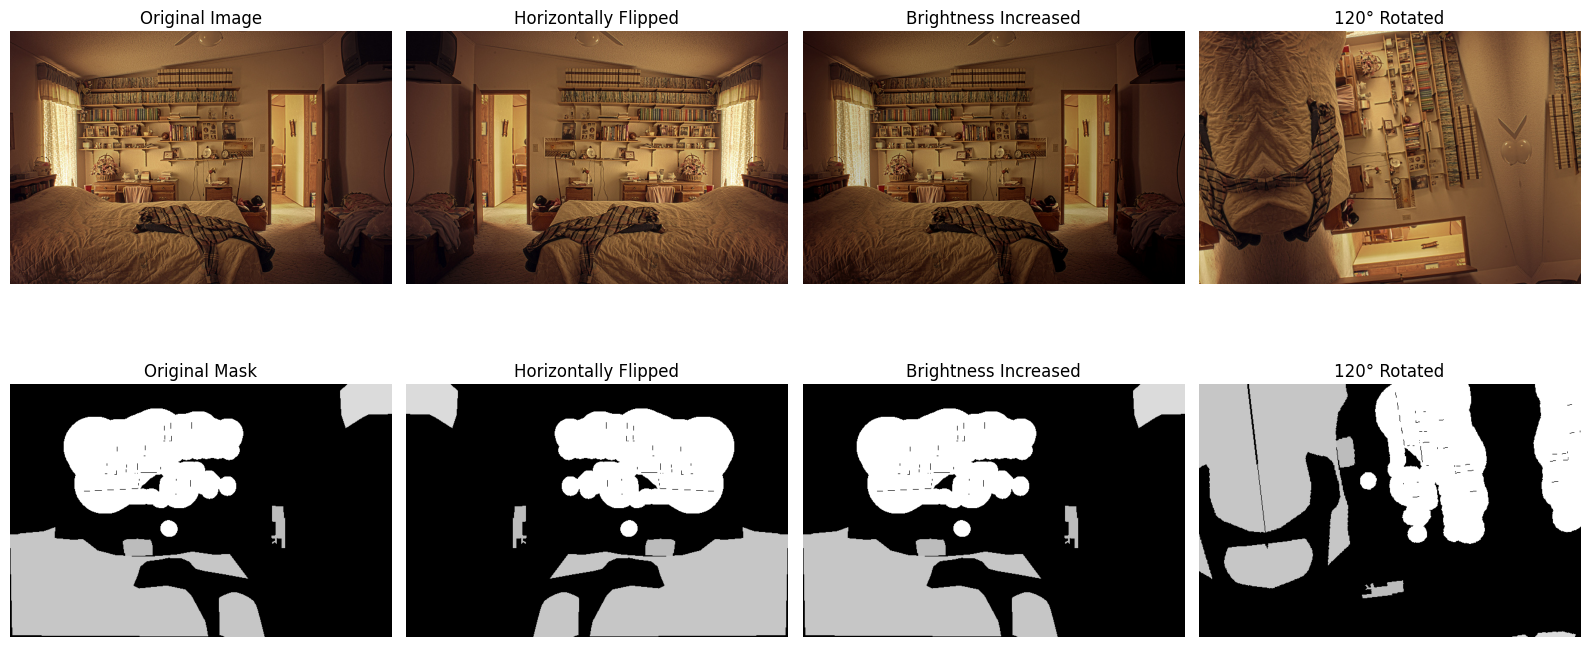

In [19]:
fig, axs = plt.subplots(2, len(augmentations), figsize=(4 * len(augmentations), 8))

for i, (title, transform) in enumerate(augmentations):
    augmented = transform(image=image, mask=mask)
    aug_img = augmented['image'].permute(1, 2, 0).numpy()
    aug_mask = augmented['mask'].numpy()

    axs[0, i].imshow(aug_img)
    axs[0, i].set_title(title)
    axs[0, i].axis('off')

    axs[1, i].imshow(aug_mask, cmap='gray')
    axs[1, i].set_title(title.replace("Image", "Mask"))
    axs[1, i].axis('off')

plt.tight_layout()
plt.show()
